Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9213 - loss: 0.2762 - val_accuracy: 0.9653 - val_loss: 0.1325
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9647 - loss: 0.1191 - val_accuracy: 0.9712 - val_loss: 0.0940
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9749 - loss: 0.0826 - val_accuracy: 0.9740 - val_loss: 0.0861
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9816 - loss: 0.0611 - val_accuracy: 0.9783 - val_loss: 0.0790
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9849 - loss: 0.0488 - val_accuracy: 0.9773 - val_loss: 0.0775
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9759 - loss: 0.0826
Test accuracy: 0.9758999943733215
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


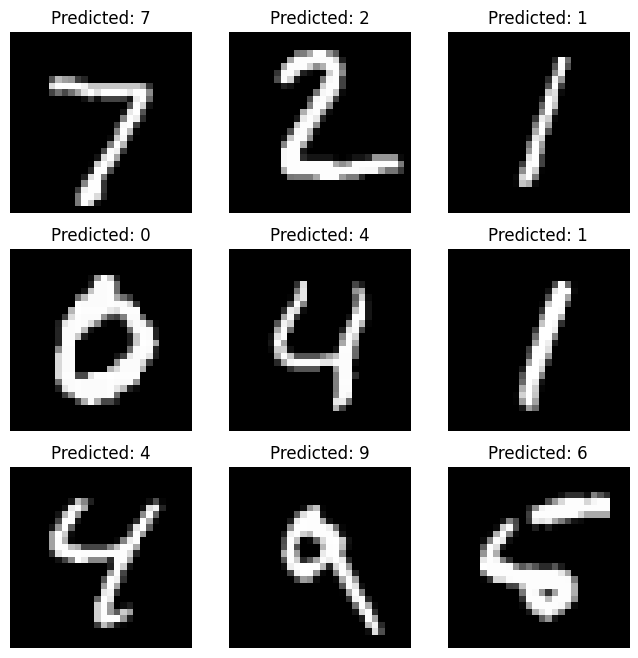

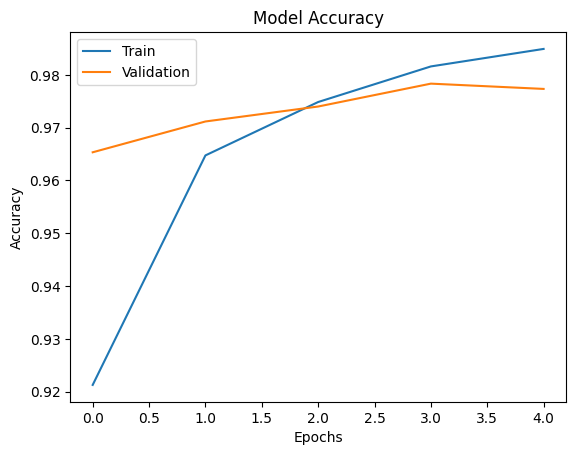

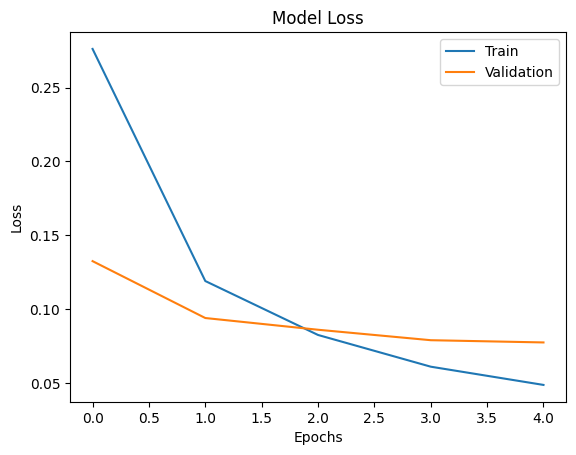

In [3]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Step 2: Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 3: Build neural network
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 4: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train model
history = model.fit(x_train, y_train,
                    epochs=5,
                    validation_split=0.1)

# Step 6: Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# -------------------------------
# VISUALIZATION
# -------------------------------

# Visualization 1: Sample predictions
predictions = model.predict(x_test)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Predicted: {}".format(np.argmax(predictions[i])))
    plt.axis('off')
plt.show()

# Visualization 2: Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Visualization 3: Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()